In [1]:
import numpy as np
from astropy.io import fits

In [2]:
import matplotlib.pyplot as plt

In [3]:
#load theory
theo = np.load("theory_29Apr_cosmogrid_params_no_IA.npy")
theo_sections = np.split(theo, 20)

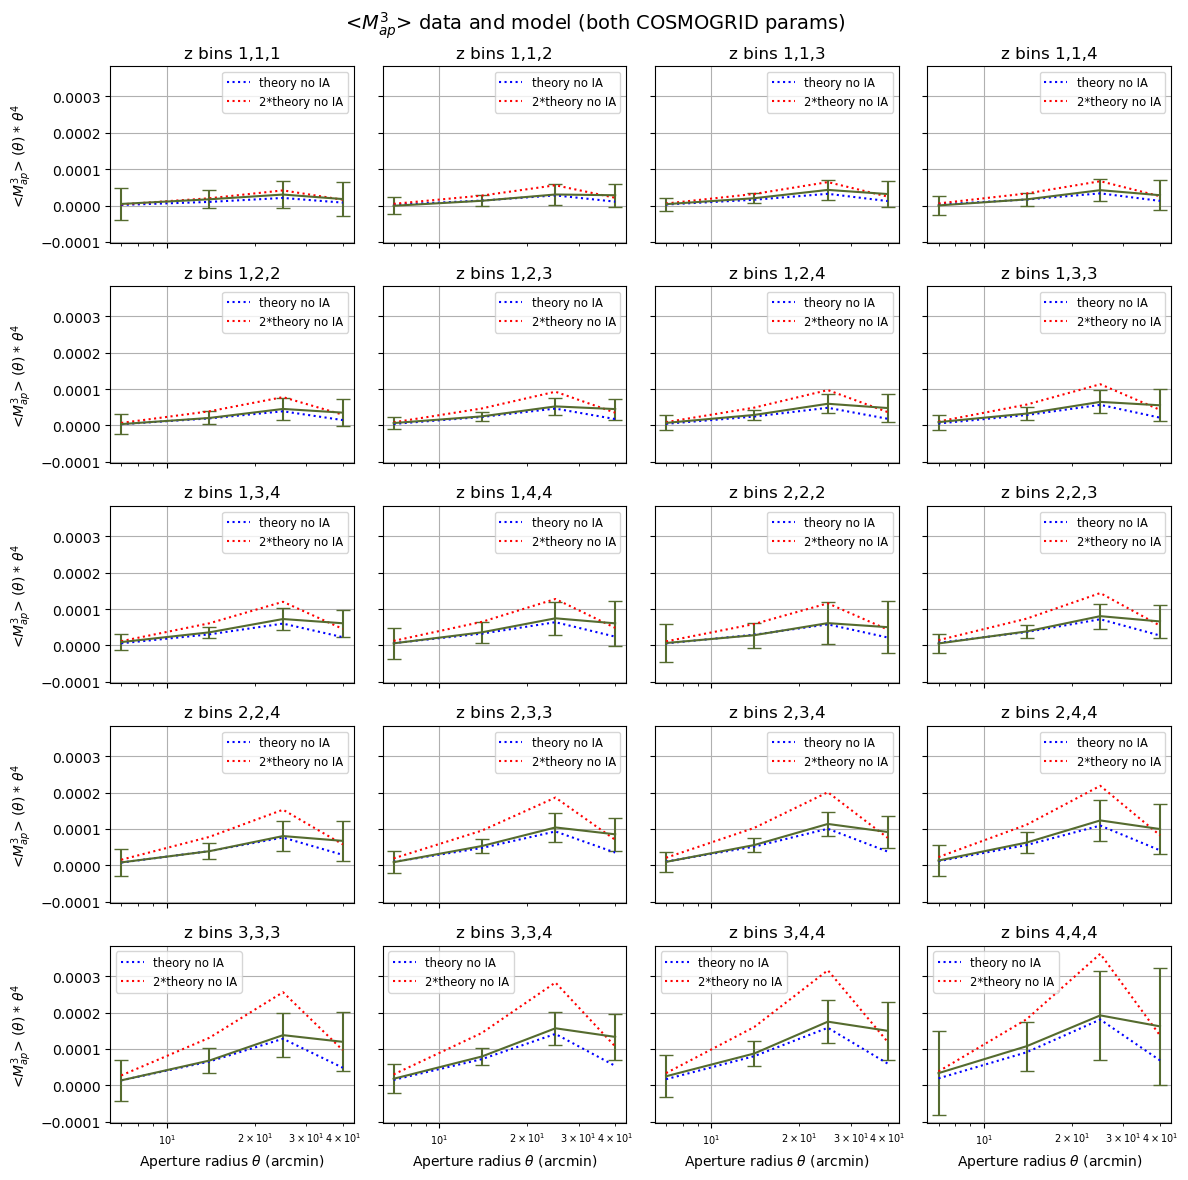

In [5]:
#NOW GET THE MEASURED DATA VECTOR AND COVARIANCE

datavector_0 = np.load("final_400sims/Apr19NOISY_scalecut_DATAVECTOR.npy")
cov = np.load("final_400sims/Apr19NOISY_scalecut_COVARIANCE_400SIMS.npy")

data_sections = np.split(datavector_0, 20)
errors = np.sqrt(np.diag(cov))

indx = [[1,1,1],[1,1,2],[1,1,3],[1,1,4],[1,2,2],[1,2,3],[1,2,4],[1,3,3],[1,3,4],[1,4,4],[2,2,2],
        [2,2,3],[2,2,4],[2,3,3],[2,3,4],[2,4,4],[3,3,3],[3,3,4],[3,4,4],[4,4,4]]

fig, axs = plt.subplots(5, 4, figsize=(12, 12), sharey=True, sharex=True)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Iterate over each subplot and plot the data
for i, ax in enumerate(axs):
    x_values = np.array([7,14,25,40])
    y_values = data_sections[i]
    ax.errorbar(x_values, x_values**4*y_values, yerr=x_values**4*errors[i*4:i*4+4], color='darkolivegreen', capsize=5)
    ax.plot(x_values, theo_sections[i]*x_values**4, color='b', ls=':',label='theory no IA')
    ax.plot(x_values, 2*theo_sections[i]*x_values**4, color='r', ls=':',label='2*theory no IA')
    ax.set_title(f'z bins {indx[i][0]},{indx[i][1]},{indx[i][2]}')
    if i >= 16:
        ax.set_xlabel(r"Aperture radius $\theta$ (arcmin)")
    
    ax.tick_params(axis='x', which='both', labelsize=7) 
        
    # Set y labels only for the leftmost column of subplots
    if i % 4 == 0:
        ax.set_ylabel(r"<$M_{ap}^3$> ($\theta$) * $\theta^4$")
        
    #ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid()
    ax.legend(fontsize='small')

fig.suptitle(r"<$M_{ap}^3$> data and model (both COSMOGRID params)", fontsize=14)
    
# Adjust layout to prevent overlap of subplots
plt.tight_layout()

# Show the plot
plt.show()